In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [11]:
data_path = Path("../data/employee_attrition_selected.csv")

if not data_path.exists():
    data_path = Path("backend/data/employee_attrition_selected.csv")

df = pd.read_csv(data_path)

X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression loaded and trained successfully!")

Logistic Regression loaded and trained successfully!


In [12]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


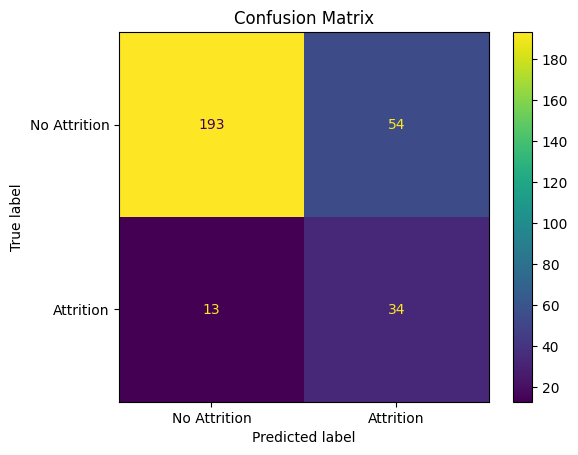

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"]
))

              precision    recall  f1-score   support

No Attrition       0.94      0.78      0.85       247
   Attrition       0.39      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.77      0.80       294



ROC curve

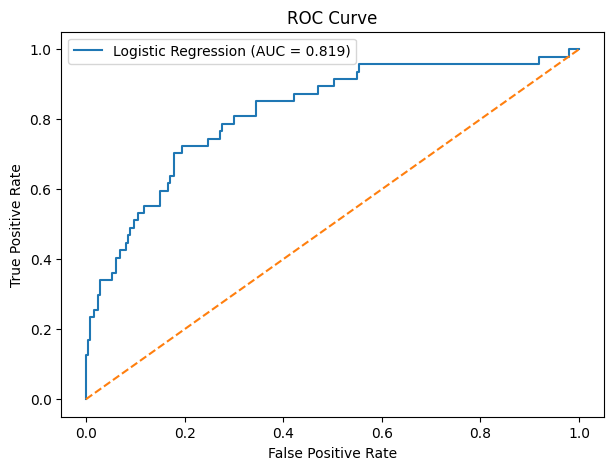

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ROC-AUC Score

In [16]:
print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8188


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc
    ]
})

evaluation.round(4)

,Metric,Score
0,Accuracy,0.7721
1,Precision,0.3864
2,Recall,0.7234
3,F1 Score,0.5037
4,ROC-AUC,0.8188


In [18]:
import joblib
from pathlib import Path

model_path = Path("../models/attrition_model.pkl")

joblib.dump(logistic_model, model_path)

print("Final model saved successfully!")
print("Model path:", model_path)

Final model saved successfully!
Model path: ..\models\attrition_model.pkl


In [19]:
import json
from pathlib import Path

metrics = {
    "model_used": "Logistic Regression",
    "accuracy": round(accuracy_score(y_test, y_pred), 4),
    "precision": round(precision_score(y_test, y_pred), 4),
    "recall": round(recall_score(y_test, y_pred), 4),
    "f1_score": round(f1_score(y_test, y_pred), 4),
    "roc_auc": round(roc_auc, 4)
}

metrics_path = Path("../models/metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics updated successfully!")
print(metrics)

Metrics updated successfully!
{'model_used': 'Logistic Regression', 'accuracy': 0.7721, 'precision': 0.3864, 'recall': 0.7234, 'f1_score': 0.5037, 'roc_auc': np.float64(0.8188)}
